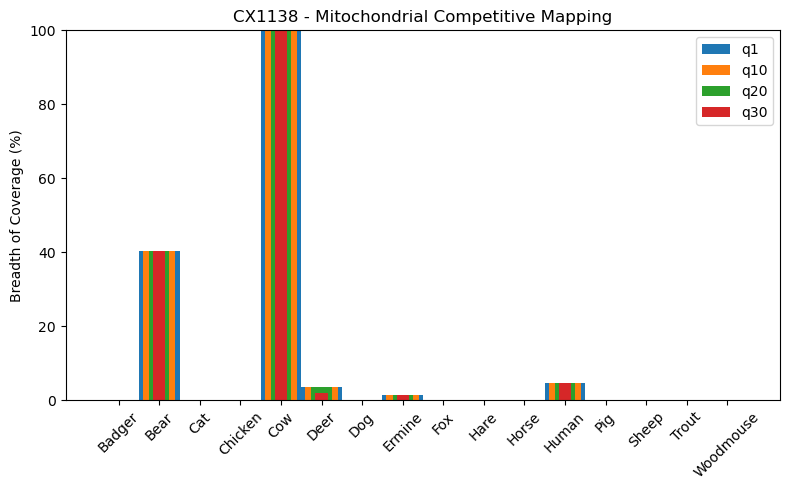

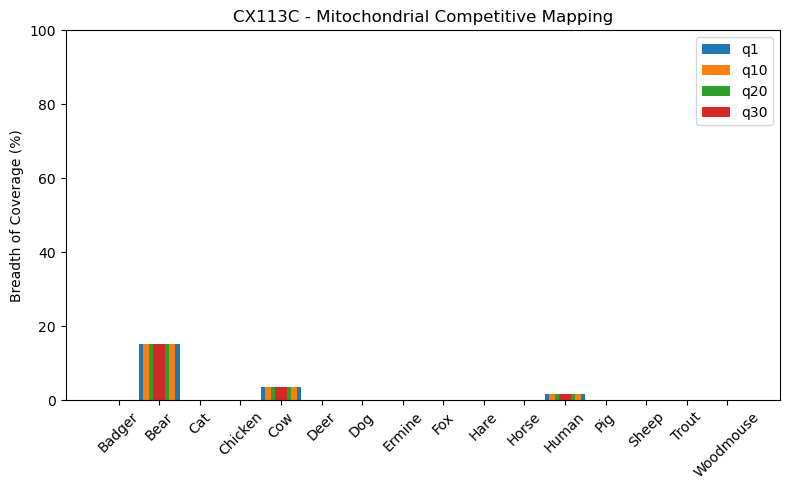

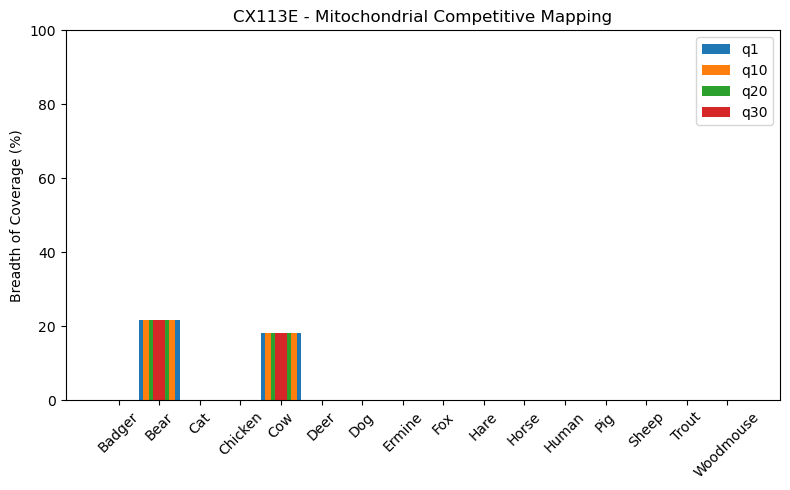

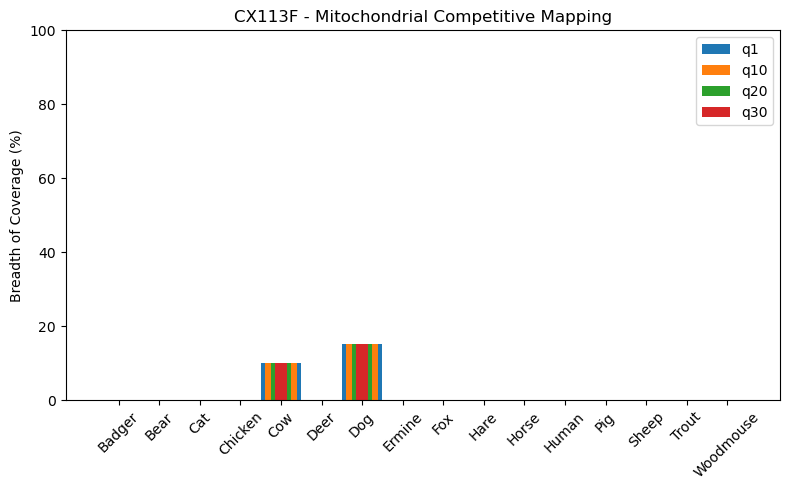

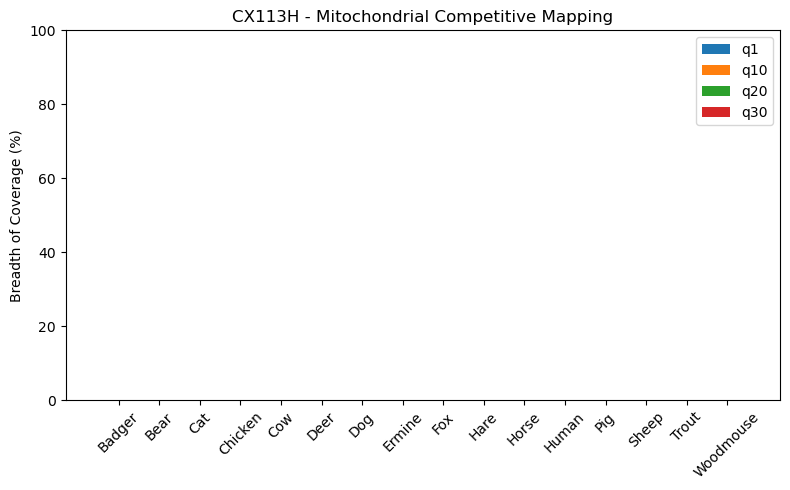

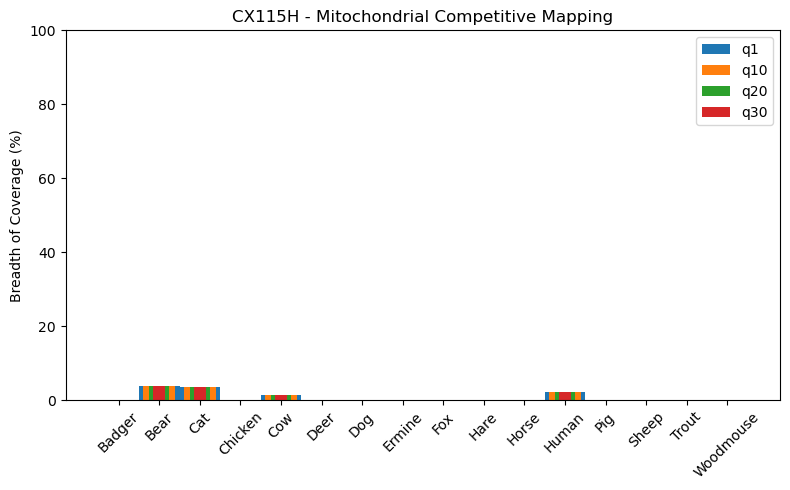

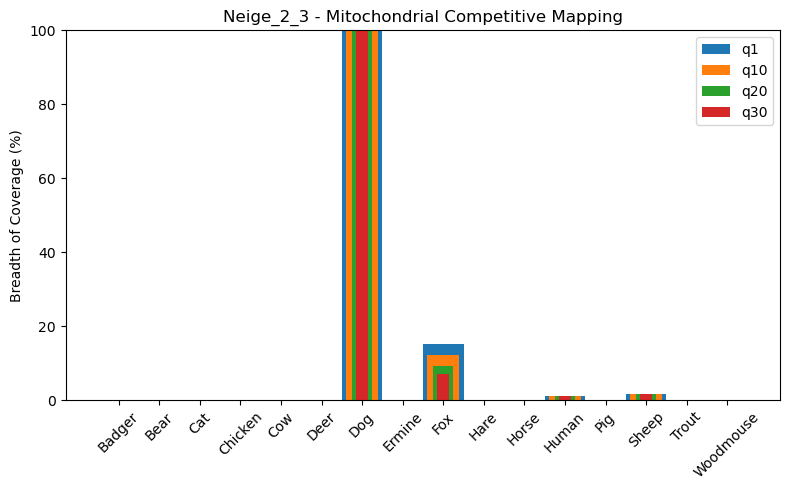

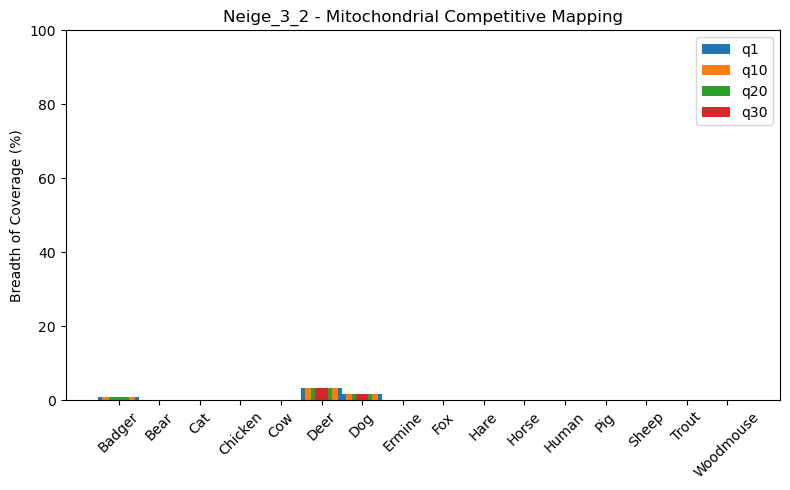

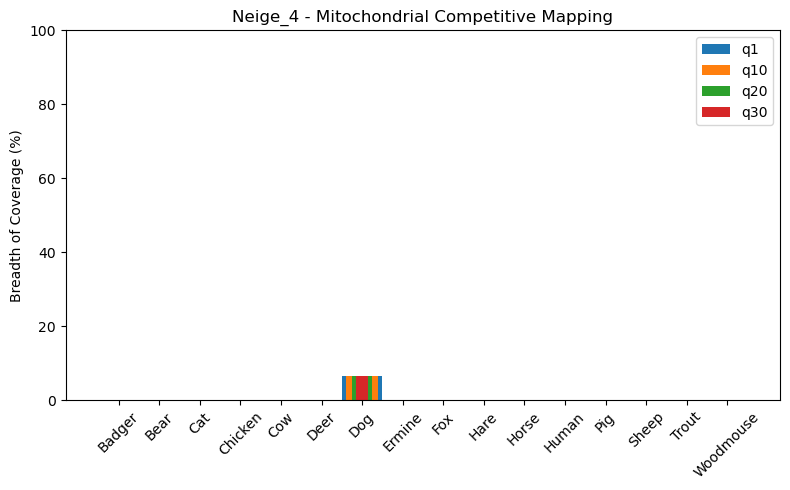

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import re

# Path to new files
data_path = "/Users/pey25guu/github_repos/snowtracks/metagenomics/competetive/mito/data"

files = glob.glob(os.path.join(data_path, "*.contig_breadth_q*.txt"))

contig_dict = {"AF303110.1":"Bear",
                "NC_002008.4":"Dog",
                "NC_012920.1":"Human",
                "CM132782.1":"Pig",
                "CM008198.1":"Cow",
                "CM020617.1":"Ermine",
                "NC_091244.1":"Horse",
                "OZ067330.1":"Fox",
                "CM028731.1":"Sheep",
                "OR915850.1":"Hare",
                "OP902891.1":"Trout",
                "NC_053523.1":"Chicken",
                "NC_001700.1":"Cat",
                "NC_025271.1":"Deer",
                "OW159452.1":"Badger",
                "OX359322.1":"Woodmouse"}

dfs = []

for f in files:
    df = pd.read_csv(f, sep=r"\s+", names=["contig", "value"])
    
    # Keep only contigs in dictionary
    df = df[df["contig"].isin(contig_dict.keys())]
    
    df["species"] = df["contig"].map(contig_dict)
    
    basename = os.path.basename(f)
    sample = re.sub(r"\.contig_breadth_q\d+\.txt$", "", basename)
    qlevel = int(re.search(r"q(\d+)", basename).group(1))
    
    df["sample"] = sample
    df["q"] = qlevel
    
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)


os.makedirs("plots", exist_ok=True)

for sample in sorted(data["sample"].unique()):
    subset = data[data["sample"] == sample]

    pivot = subset.pivot(index="species", columns="q", values="value")
    pivot = pivot.reindex(columns=[1, 10,20,30], fill_value=0)

    x = range(len(pivot.index))

    plt.figure(figsize=(8,5))
    plt.bar(x, pivot[1], width=1, label="q1")
    plt.bar(x, pivot[10], width=0.8, label="q10")
    plt.bar(x, pivot[20], width=0.5, label="q20")
    plt.bar(x, pivot[30], width=0.3, label="q30")

    plt.xticks(x, pivot.index, rotation=45)
    plt.ylabel("Breadth of Coverage (%)")
    plt.title(f"{sample} - Mitochondrial Competitive Mapping")
    plt.ylim(0,100)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"plots/{sample}_overlay.png")
    plt.show()
